In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_istat=pd.read_csv('dataset_incidenti_B.csv', sep=',')
display(df_istat.head())
display(df_istat.info())
display(df_istat[['Numero_Incidenti','Numero_Feriti','Numero_Morti','Numero_Totale_Morti_Feriti','Tasso_Incidenti']].describe())

,Anno,Codice_Comune,Numero_Incidenti,Numero_Feriti,Numero_Morti,Numero_Totale_Morti_Feriti,Comune,Popolazione,Tasso_Incidenti
0,2014,1008,39,56,0,56,Alpignano,17370,2.245250
1,2014,1013,39,58,0,58,Avigliana,12445,3.133789
2,2014,1024,52,71,1,72,Beinasco,18213,2.855103
3,2014,1028,24,36,0,36,Borgaro Torinese,13424,1.787843
4,2014,1034,14,18,0,18,Brandizzo,8609,1.626205


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21269 entries, 0 to 21268
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Anno                        21269 non-null  int64  
 1   Codice_Comune               21269 non-null  int64  
 2   Numero_Incidenti            21269 non-null  int64  
 3   Numero_Feriti               21269 non-null  int64  
 4   Numero_Morti                21269 non-null  int64  
 5   Numero_Totale_Morti_Feriti  21269 non-null  int64  
 6   Comune                      21269 non-null  object 
 7   Popolazione                 21269 non-null  int64  
 8   Tasso_Incidenti             21269 non-null  float64
dtypes: float64(1), int64(7), object(1)
memory usage: 1.5+ MB


None

,Numero_Incidenti,Numero_Feriti,Numero_Morti,Numero_Totale_Morti_Feriti,Tasso_Incidenti
count,21269.000000,21269.000000,21269.000000,21269.000000,21269.000000
mean,71.906202,98.775918,1.156472,99.932390,2.451430
std,375.316399,484.272492,3.865834,487.769112,1.272536
min,6.000000,5.000000,0.000000,6.000000,0.280243
25%,14.000000,20.000000,0.000000,20.000000,1.548787
50%,24.000000,35.000000,0.000000,36.000000,2.214984
75%,49.000000,71.000000,1.000000,72.000000,3.062653
max,13924.000000,17667.000000,173.000000,17821.000000,15.539912


Da questa analisi si può osservare che la stragrande maggioranza dei comuni (più del 50%) ha un numero di incidenti contenuto (meno di 24 incidenti all'anno) ma la media è più alta a causa di alcuni comuni (le metropoli) che spingono la media verso l'alto. Si può inoltre osservare che il tasso di incidenti livella le differenze geografiche. Ha infatti una deviazione standard molto più contenuta rispetto alle variabili assolute. Si può inoltre osservare la presenza di Outlier estremi, con comuni che registrano un massimo di 13924 incidenti in un anno con numero di morti 173.

In [48]:

# Raggruppo sia per Anno che per Comune, calcolo la somma e ordino dal valore più alto
classifica_annuale = df_istat.groupby(['Anno', 'Comune'])['Numero_Incidenti'].sum().sort_values(ascending=False)
display(classifica_annuale.head(10))

#Studio quali città hanno il massimo numero di incidenti in termini assoluti
df_istat.groupby('Comune')['Numero_Incidenti'].sum().sort_values(ascending=False).head(10)

,,Numero_Incidenti
Anno,Comune,
2024,Roma,13924
2014,Roma,13501
2016,Roma,13241
2022,Roma,13181
2015,Roma,13128
2017,Roma,12886
2023,Roma,12817
2019,Roma,12271
2018,Roma,11995


,Numero_Incidenti
Comune,
Roma,128073
Milano,82771
Genova,40123
Torino,30069
Firenze,24966
Napoli,23265
Palermo,19956
Bologna,19789
Bari,15928


Come previsto si può osservare che il massimo numero di incidenti in termini assoluti si registra nelle metropoli (dove la popolazione è maggiore) perciò non è un indicatore attendibile. Provo quindi a vedere il tasso di incidenti medio su ogni comune.

In [49]:
#Calcolo il tasso di incidenti medio su ogni comune e ididentifico i comuni più pericolosi
classifica_tasso = df_istat.groupby('Comune')['Tasso_Incidenti'].mean().sort_values(ascending=False).round(2)
display(classifica_tasso.head(10))

,Tasso_Incidenti
Comune,
Forte dei Marmi,14.45
Bentivoglio,9.39
Assago,8.12
Lignano Sabbiadoro,7.99
Lavagna,7.83
Santa Margherita Ligure,7.67
Bergamo,7.46
Calenzano,7.34
Jesolo,7.08


Si può osservare che nelle prime 10 posizioni per tasso di incidenti si collocano principalmente località turistiche. L'alto tasso di incidenti è dovuto al fatto che in certi momenti dell'anno la densità di popolazione aumenta ma il denominatore usato per l'analisi è costante in quanto si tratta della popolazione residente.
Creo perciò una colonna che indichi il tasso di mortalità.

In [50]:
df_istat['Indice_Mortalita'] = (df_istat['Numero_Morti'] / df_istat['Numero_Incidenti']).round(2) * 100

print(df_istat)

classifica_mortalità = df_istat.groupby('Comune')['Indice_Mortalita'].mean().sort_values(ascending=False)
display(classifica_mortalità.head(10))

       Anno  Codice_Comune  Numero_Incidenti  Numero_Feriti  Numero_Morti  \
0      2014           1008                39             56             0   
1      2014           1013                39             58             0   
2      2014           1024                52             71             1   
3      2014           1028                24             36             0   
4      2014           1034                14             18             0   
...     ...            ...               ...            ...           ...   
21264  2024         110006                 9             18             0   
21265  2024         110007                24             32             0   
21266  2024         110008                15             32             0   
21267  2024         110009               165            256             2   
21268  2024         110010                46             89             4   

       Numero_Totale_Morti_Feriti                    Comune  Popolazione  \

,Indice_Mortalita
Comune,
Marineo,33.000000
Sassano,33.000000
Muro Leccese,31.000000
Monteiasi,29.000000
Lesina,26.333333
Vairano Patenora,25.000000
Misinto,25.000000
Cerda,22.000000
Fara Gera d'Adda,22.000000


Si può osservare la presenza di piccoli comuni in cima alla classifica. Questo probabilmente è dovuto alla presenza di strade non perfette.Si studia adesso la classifica per gravità e per frequenza urbana

In [51]:
# CLASSIFICA PER GRAVITÀ (Indice di Mortalità)


classifica_mortalità = df_istat.groupby('Comune')['Indice_Mortalita'].mean().sort_values(ascending=False).head(10)

#CLASSIFICA PER FREQUENZA URBANA (Tasso di Incidentalità filtrato per popolazione)
# Escludo i piccoli comuni sotto i 40.000 abitanti per rimuovere il bias turistico/di passaggio
comuni_grandi = df_istat[df_istat['Popolazione'] > 40000]

top_frequenza = comuni_grandi.groupby('Comune')['Tasso_Incidenti'].mean().sort_values(ascending=False).head(10)

print("--- TOP 10 COMUNI PER INDICE DI MORTALITÀ (Gravità) ---")
print(classifica_mortalità)
print("\n--- TOP 10 COMUNI GRANDI PER TASSO DI INCIDENTALITÀ (Frequenza Urbana) ---")
print(top_frequenza)

--- TOP 10 COMUNI PER INDICE DI MORTALITÀ (Gravità) ---
Comune
Marineo             33.000000
Sassano             33.000000
Muro Leccese        31.000000
Monteiasi           29.000000
Lesina              26.333333
Vairano Patenora    25.000000
Misinto             25.000000
Cerda               22.000000
Fara Gera d'Adda    22.000000
Custonaci           20.250000
Name: Indice_Mortalita, dtype: float64

--- TOP 10 COMUNI GRANDI PER TASSO DI INCIDENTALITÀ (Frequenza Urbana) ---
Comune
Bergamo                     7.459
Genova                      7.039
Firenze                     6.760
Sanremo                     6.537
Pisa                        6.523
Rimini                      6.337
Livorno                     6.201
Savona                      6.160
Milano                      6.052
San Benedetto del Tronto    5.952
Name: Tasso_Incidenti, dtype: float64


L'analisi dimostra che il concetto di 'pericolosità stradale' deve essere segmentato. Da un lato, i grandi centri urbani presentano un'elevata frequenza di sinistri legata al traffico (alto Tasso di Incidentalità), ma con bassa letalità. Dall'altro, i comuni più piccoli e isolati presentano una bassa frequenza ma un'elevatissima gravità (alto Indice di Mortalità), identificando i tratti extraurbani dove gli impatti sono più critici.

In [52]:
ts_nazionale = df_istat.groupby('Anno')['Numero_Incidenti'].sum().reset_index()
correlazione_trend = ts_nazionale['Anno'].corr(ts_nazionale['Numero_Incidenti'])
print(f"Coefficiente di Pearson (Anno vs Incidenti): {correlazione_trend:.3f}")

Coefficiente di Pearson (Anno vs Incidenti): -0.575


 Prima di procedere con la fase di modellazione predittiva, si è calcolato l'indice di correlazione di Pearson tra la variabile temporale (Anno) e il volume totale dei sinistri. Il risultato ($r = -0.575$) evidenzia una moderata e stabile correlazione lineare negativa. Questo legame matematico certifica la presenza di un trend decrescente nel corso del decennio e giustifica l'applicazione di un modello di Regressione quadratica per stimare il forecasting degli incidenti per gli anni futuri (2025-2027)

 MODELLO QUADRATICO (POLINOMIALE GRADO 2)
Coefficiente di determinazione R²: 0.438


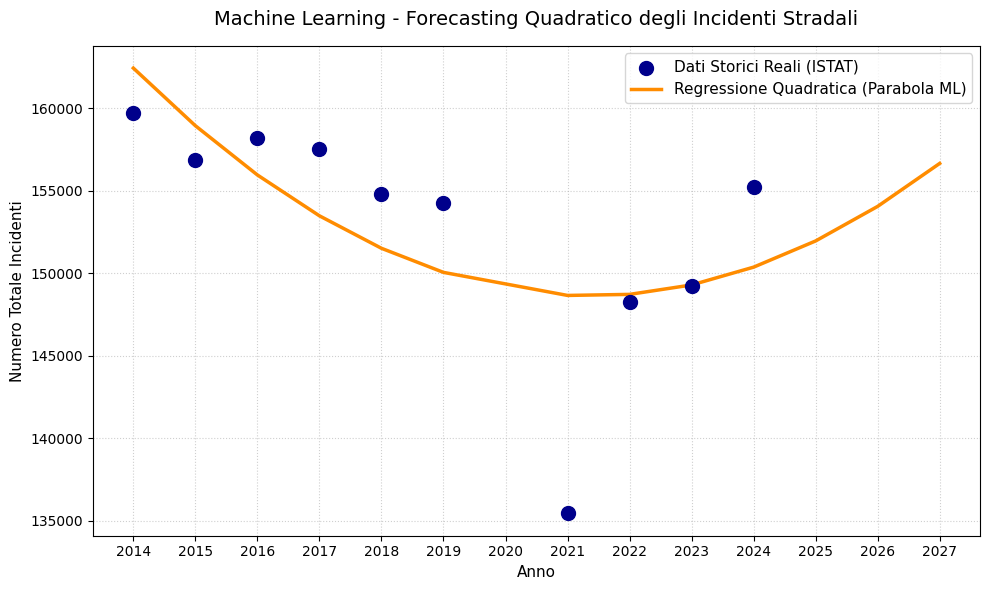

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Dati storici (Serie storica nazionale)
ts_nazionale = df_istat.groupby('Anno')['Numero_Incidenti'].sum().reset_index()
X = ts_nazionale['Anno'].values.reshape(-1, 1)
y = ts_nazionale['Numero_Incidenti'].values

# Trasformazione Quadratica (Grado 2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Addestramento del modello
modello_quadratico = LinearRegression()
modello_quadratico.fit(X_poly, y)

# Metriche di performance
r2_quadratico = modello_quadratico.score(X_poly, y)
print(f" MODELLO QUADRATICO (POLINOMIALE GRADO 2)")
print(f"Coefficiente di determinazione R²: {r2_quadratico:.3f}")


#Forecasting fino al 2027
anni_totali = np.array(sorted(list(ts_nazionale['Anno'].unique()) + [2025, 2026, 2027])).reshape(-1, 1)
anni_totali_poly = poly_features.transform(anni_totali)
y_pred_quadratico = modello_quadratico.predict(anni_totali_poly)

#Grafico finale
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='darkblue', s=100, label='Dati Storici Reali (ISTAT)', zorder=3)
plt.plot(anni_totali, y_pred_quadratico, color='darkorange', linestyle='-', linewidth=2.5, label='Regressione Quadratica (Parabola ML)')

plt.title('Machine Learning - Forecasting Quadratico degli Incidenti Stradali', fontsize=14, pad=15)
plt.xlabel('Anno', fontsize=11)
plt.ylabel('Numero Totale Incidenti', fontsize=11)
plt.xticks(np.arange(anni_totali.min(), anni_totali.max()+1, 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [54]:
#Recupero solo gli anni di interesse per il forecasting
anni_forecast = np.array([2025, 2026, 2027]).reshape(-1, 1)

#Trasformazione quadratica per gli anni del forecast
anni_forecast_poly = poly_features.transform(anni_forecast)

#Calcolo delle previsioni esplicite
predizioni_future = modello_quadratico.predict(anni_forecast_poly)


print("PREVISIONI NUMERICHE IMPATTO INCIDENTI (2025-2027)")
for anno, pred in zip(anni_forecast.flatten(), predizioni_future):
    print(f"Anno {anno}: {int(round(pred))} incidenti stimati a livello nazionale")

PREVISIONI NUMERICHE IMPATTO INCIDENTI (2025-2027)
Anno 2025: 151954 incidenti stimati a livello nazionale
Anno 2026: 154048 incidenti stimati a livello nazionale
Anno 2027: 156650 incidenti stimati a livello nazionale


In [55]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# PREPARAZIONE DEL DATASET PER IL CLUSTERING
#Raggruppo per Comune e calcolo la media delle metriche chiave nel decennio
df_cluster = df_istat.groupby('Comune').agg({
    'Numero_Incidenti': 'mean',
    'Tasso_Incidenti': 'mean',
    'Indice_Mortalita': 'mean'
}).reset_index()

#Selezione delle feauture e scaling (Normalizzazione)
features = ['Numero_Incidenti', 'Tasso_Incidenti', 'Indice_Mortalita']
X_cluster = df_cluster[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

#Addestramento di K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled) # Addestra il modello

#Assegno le etichette reali generate dall'algoritmo (saranno 0, 1 e 2)
df_cluster['Cluster'] = kmeans.labels_
# 1. Raggruppa il dataframe originale per la colonna 'Cluster'
# 2. Calcola la media (mean) delle colonne che ti interessano
centroids_reali = df_cluster.groupby('Cluster')[['Numero_Incidenti', 'Tasso_Incidenti', 'Indice_Mortalita']].mean().reset_index()

# Mostra i veri centroidi a schermo per controllare se i numeri hanno senso
print(centroids_reali)

#Guardo chi c'è nei cluster
print("\nESEMPIO COMUNI NEL CLUSTER 0 ")
print(df_cluster[df_cluster['Cluster'] == 0]['Comune'].head(5).values)
print("\n ESEMPIO COMUNI NEL CLUSTER 1")
print(df_cluster[df_cluster['Cluster'] == 1]['Comune'].head(5).values)
print("\nESEMPIO COMUNI NEL CLUSTER 2")
print(df_cluster[df_cluster['Cluster'] == 2]['Comune'].head(5).values)

   Cluster  Numero_Incidenti  Tasso_Incidenti  Indice_Mortalita
0        0         25.459497         1.880938          3.252955
1        1        166.044013         3.994706          1.724484
2        2      10542.200000         5.327500          0.800000

ESEMPIO COMUNI NEL CLUSTER 0 
['Abano Terme' 'Abbadia San Salvatore' 'Acate' 'Acerra' 'Aci Castello']

 ESEMPIO COMUNI NEL CLUSTER 1
['Abbiategrasso' 'Acireale' 'Agrate Brianza' 'Agrigento' 'Agropoli']

ESEMPIO COMUNI NEL CLUSTER 2
['Milano' 'Roma']


In [15]:
print(df_cluster['Cluster'].unique())

[0 1 2]


Il clustering non supervisionato dimostra che allocare i fondi per la sicurezza basandosi solo sul numero assoluto di incidenti sarebbe un grave errore strategico, poiché penalizzerebbe il Cluster 0 (comuni extraurbani). Sebbene questi territori registrino pochi sinistri, presentano un tasso di letalità del 3.3%, configurandosi come la vera priorità per gli interventi infrastrutturali salvavita.

In [39]:
# Assegno i cluster direttamente al DataFrame originale così non perdo i Comuni
df_cluster['Cluster'] = kmeans.labels_

# Creo il dataset finale includendo la colonna 'Comune'
df_clusters = df_cluster[['Comune', 'Cluster', 'Numero_Incidenti', 'Tasso_Incidenti', 'Indice_Mortalita']]



#Salvo lo storico nazionale (punti blu del grafico)
ts_nazionale.to_csv('storico_nazionale_definitivo8.csv', index=False, encoding='utf-8')

#Salvo le previsioni future 2025-2027 (linea arancione del forecast)
df_forecast = pd.DataFrame({
    'Anno': [2025, 2026, 2027],
    'Numero_Incidenti': predizioni_future
})
df_forecast.to_csv('previsioni_future_definitivo8.csv', index=False, encoding='utf-8')

In [45]:
# Carico i due file
storico = pd.read_csv('storico_nazionale_definitivo8.csv')
previsioni = pd.read_csv('previsioni_future_definitivo8.csv')

#Rinomino la colonna delle previsioni per farla combaciare con lo storico
previsioni = previsioni.rename(columns={'Incidenti_Previsionali': 'Numero_Incidenti'})

#Incollo il futuro sotto il passato (Concat)
linea_tempo_unica = pd.concat([storico, previsioni], ignore_index=True)
linea_tempo_unica=linea_tempo_unica[['Anno','Numero_Incidenti']].astype(int)

#Salvo il nuovo file
linea_tempo_unica.to_csv('linea_tempo_completa_definitiva11.csv', index=False,encoding='utf-8')

In [47]:
df_clusters['Numero_Incidenti'] = df_clusters['Numero_Incidenti'].astype(int)
df_clusters['Tasso_Incidenti'] = df_clusters['Tasso_Incidenti'].round(2)
df_clusters['Indice_Mortalita'] = df_clusters['Indice_Mortalita'].round(2)
df_clusters.to_csv('incidenti_clusters_definitivo_11.csv', index=False, sep=';', decimal=',')
